# Late Fusion (TF-IDF+LR 확률 + BERT+MLP 확률 가중합)

- `P_final = alpha * P(LR) + (1 - alpha) * P(MLP)`
- alpha in {0.0, ..., 1.0}, **val에서 best alpha 선택**, test는 1회
- LR 파라미터: baseline 튜닝값 (C=1, ngram(1,1), max_features=10000, balanced)
- **선행:** `bert_mlp.ipynb` 실행해 `mlp_val_proba.npy`, `mlp_test_proba.npy` 저장돼 있어야 함

In [1]:
import os, time, numpy as np, pandas as pd

# 스모크 테스트: True면 클래스별 소량 샘플만 사용 (파이프라인 점검용)
SMOKE_TEST = False
N_SMOKE = 1000

def find_root(start='.'):
    p = os.path.abspath(start)
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'processed_data')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(start)

ROOT = find_root()
DATA_DIR = os.path.join(ROOT, 'processed_data')
ART_DIR = os.path.join(ROOT, 'artifacts')
os.makedirs(ART_DIR, exist_ok=True)
print('ROOT     :', ROOT)
print('DATA_DIR :', DATA_DIR)
print('ART_DIR  :', ART_DIR)

ROOT     : /workspace/big_data_programming-LEON
DATA_DIR : /workspace/big_data_programming-LEON/processed_data
ART_DIR  : /workspace/big_data_programming-LEON/artifacts


In [2]:
# 라벨 순서 (label_mapping.csv 기준: 인덱스 = label 값)
LABEL_NAMES = ['가사', '개인정보/ICT', '근로자', '금융조세', '기업',
               '민사', '특허/저작권', '행정', '형사A(생활형)', '형사B(일반형)']
N_CLASS = 10

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [4]:
label_map = pd.read_csv(os.path.join(DATA_DIR, 'label_mapping.csv'))
label_map.columns = label_map.columns.str.strip()
CLASS_TO_LABEL = dict(zip(label_map['class_name'], label_map['label']))

def load_split(name):
    """결합 입력(text = 판시사항 + 요약문)과 라벨 반환."""
    df = pd.read_csv(os.path.join(DATA_DIR, name + '.csv'))
    df.columns = df.columns.str.strip()

    if 'label' not in df.columns:
        if 'class_name' not in df.columns:
            raise KeyError(f"{name}.csv에 label/class_name 컬럼이 없습니다: {df.columns.tolist()}")
        df['label'] = df['class_name'].map(CLASS_TO_LABEL)

    df['label'] = df['label'].astype(int)

    if SMOKE_TEST:
        per = max(2, N_SMOKE // N_CLASS)
        parts = []
        for _, g in df.groupby('label', sort=True):
            parts.append(g.sample(min(len(g), per), random_state=42))
        df = pd.concat(parts, ignore_index=True)

    text = (df['jdgmn'].fillna('') + ' ' + df['summ_pass'].fillna('')).tolist()
    labels = df['label'].to_numpy()
    return text, labels

In [5]:
tr_text, ytr = load_split('train')
val_text, yval = load_split('val')
te_text, yte = load_split('test')

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
Xtr = tfidf.fit_transform(tr_text)
lr = LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(Xtr, ytr)
lr_val = lr.predict_proba(tfidf.transform(val_text))
lr_test = lr.predict_proba(tfidf.transform(te_text))
print('LR classes:', lr.classes_.tolist())

LR classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
mlp_val = np.load(os.path.join(ART_DIR, 'mlp_val_proba.npy'))
mlp_test = np.load(os.path.join(ART_DIR, 'mlp_test_proba.npy'))
assert lr_val.shape == mlp_val.shape, (lr_val.shape, mlp_val.shape)
print('shapes OK:', lr_val.shape, mlp_val.shape)

shapes OK: (4260, 10) (4260, 10)


In [7]:
alphas = np.linspace(0, 1, 11)
val_f1s = []
for a in alphas:
    p = a * lr_val + (1 - a) * mlp_val
    val_f1s.append(f1_score(yval, p.argmax(1), average='macro'))
best_i = int(np.argmax(val_f1s))
best_alpha = alphas[best_i]
print(f'best alpha = {best_alpha:.1f}  (val F1-macro {val_f1s[best_i]:.4f})')
for a, f in zip(alphas, val_f1s):
    print(f'  alpha={a:.1f}  val F1={f:.4f}')

best alpha = 0.8  (val F1-macro 0.6669)
  alpha=0.0  val F1=0.6003
  alpha=0.1  val F1=0.6135
  alpha=0.2  val F1=0.6181
  alpha=0.3  val F1=0.6298
  alpha=0.4  val F1=0.6434
  alpha=0.5  val F1=0.6529
  alpha=0.6  val F1=0.6607
  alpha=0.7  val F1=0.6667
  alpha=0.8  val F1=0.6669
  alpha=0.9  val F1=0.6621
  alpha=1.0  val F1=0.6559


In [8]:
p_test = best_alpha * lr_test + (1 - best_alpha) * mlp_test
yp = p_test.argmax(1)
print(f'TEST (alpha={best_alpha:.1f})  Accuracy {accuracy_score(yte, yp):.4f}  |  F1-macro {f1_score(yte, yp, average="macro"):.4f}  (baseline 0.6347)')
print(classification_report(yte, yp, target_names=LABEL_NAMES, digits=4))

TEST (alpha=0.8)  Accuracy 0.7073  |  F1-macro 0.6561  (baseline 0.6347)
              precision    recall  f1-score   support

          가사     0.5722    0.7984    0.6667       129
    개인정보/ICT     0.3455    0.7037    0.4634        27
         근로자     0.6279    0.7895    0.6995       171
        금융조세     0.5984    0.8192    0.6916       271
          기업     0.2212    0.5000    0.3067       138
          민사     0.9004    0.7174    0.7985      1525
      특허/저작권     0.9380    0.9625    0.9501       267
          행정     0.7244    0.6248    0.6709       589
    형사A(생활형)     0.6450    0.7302    0.6850       530
    형사B(일반형)     0.6780    0.5863    0.6288       614

    accuracy                         0.7073      4261
   macro avg     0.6251    0.7232    0.6561      4261
weighted avg     0.7490    0.7073    0.7190      4261



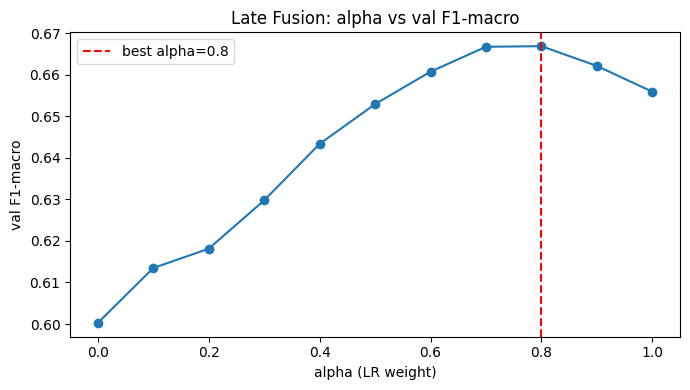

In [9]:
# alpha vs val F1 그래프 (H3 해석용)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, val_f1s, marker='o')
ax.axvline(best_alpha, color='red', ls='--', label=f'best alpha={best_alpha:.1f}')
ax.set_xlabel('alpha (LR weight)'); ax.set_ylabel('val F1-macro')
ax.set_title('Late Fusion: alpha vs val F1-macro'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ART_DIR, 'late_fusion_alpha.png'), dpi=150)
plt.show()